In [1]:
from graphviz import Digraph
from IPython.display import Image, display
import os

In [2]:
INPUT_COLOR = "#d6eaf8"
FEATURE_COLOR = "#d5f5e3"
ENCODER_COLOR = "#fdebd0"
SPECIAL_COLOR = "#f9e79f"
OUTPUT_COLOR = "#fadbd8"
AUX_COLOR = "#e8daef"

In [3]:
def draw_model_diagram(model_name, blocks, edges, output_dir="model_diagrams", view=True):
    os.makedirs(output_dir, exist_ok=True)

    dot = Digraph(name=model_name, format="png")
    dot.attr(rankdir="LR", splines="ortho", nodesep="0.5", ranksep="0.7")
    dot.attr(label=model_name, labelloc="t", fontsize="20", fontname="Helvetica-Bold")

    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        color="#2c3e50",
        fillcolor="#ecf0f1",
        fontname="Helvetica",
        fontsize="11",
        margin="0.18,0.10"
    )

    for block_id, label, fillcolor in blocks:
        dot.node(block_id, label=label, fillcolor=fillcolor)

    dot.attr("edge", color="#34495e", arrowsize="0.8", penwidth="1.2")

    for src, dst, edge_label in edges:
        if edge_label:
            dot.edge(src, dst, label=edge_label, fontsize="10")
        else:
            dot.edge(src, dst)

    out_path = os.path.join(output_dir, model_name.replace(" ", "_").lower())
    dot.render(out_path, cleanup=True)

    if view:
        display(Image(filename=out_path + ".png"))

    return out_path + ".png"

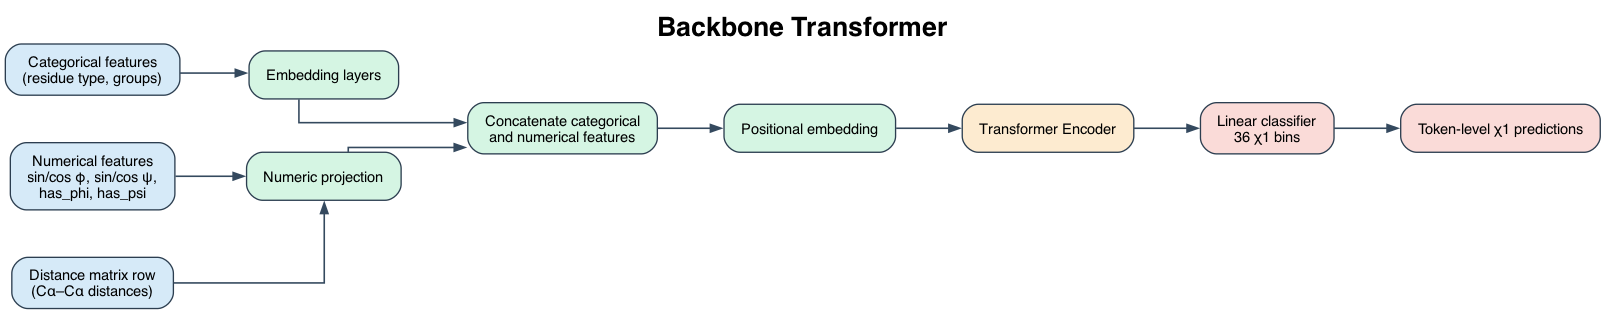

'model_diagrams/backbone_transformer.png'

In [4]:
backbone_blocks = [
    ("cat", "Categorical features\n(residue type, groups)", INPUT_COLOR),
    ("num", "Numerical features\nsin/cos φ, sin/cos ψ,\nhas_phi, has_psi", INPUT_COLOR),
    ("dist", "Distance matrix row\n(Cα–Cα distances)", INPUT_COLOR),
    ("emb", "Embedding layers", FEATURE_COLOR),
    ("fc", "Numeric projection", FEATURE_COLOR),
    ("merge", "Concatenate categorical\nand numerical features", FEATURE_COLOR),
    ("pos", "Positional embedding", FEATURE_COLOR),
    ("enc", "Transformer Encoder", ENCODER_COLOR),
    ("clf", "Linear classifier\n36 χ1 bins", OUTPUT_COLOR),
    ("out", "Token-level χ1 predictions", OUTPUT_COLOR),
]

backbone_edges = [
    ("cat", "emb", ""),
    ("num", "fc", ""),
    ("dist", "fc", ""),
    ("emb", "merge", ""),
    ("fc", "merge", ""),
    ("merge", "pos", ""),
    ("pos", "enc", ""),
    ("enc", "clf", ""),
    ("clf", "out", ""),
]

draw_model_diagram("Backbone Transformer", backbone_blocks, backbone_edges)

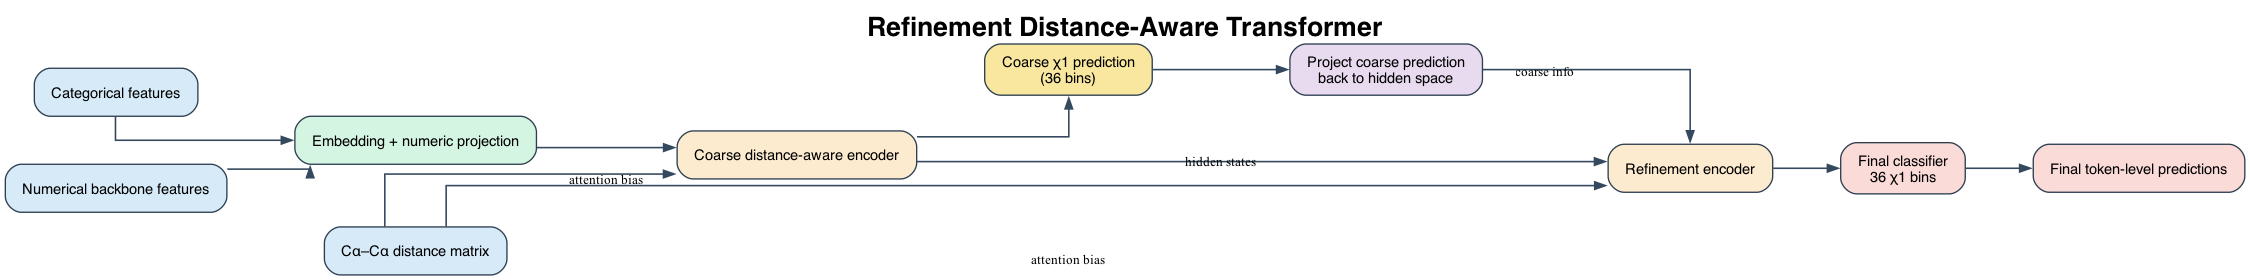

'model_diagrams/refinement_distance-aware_transformer.png'

In [5]:
refinement_blocks = [
    ("cat", "Categorical features", INPUT_COLOR),
    ("num", "Numerical backbone features", INPUT_COLOR),
    ("dist", "Cα–Cα distance matrix", INPUT_COLOR),
    ("inp", "Embedding + numeric projection", FEATURE_COLOR),
    ("coarse", "Coarse distance-aware encoder", ENCODER_COLOR),
    ("coarse_logits", "Coarse χ1 prediction\n(36 bins)", SPECIAL_COLOR),
    ("proj_back", "Project coarse prediction\nback to hidden space", AUX_COLOR),
    ("refine", "Refinement encoder", ENCODER_COLOR),
    ("final", "Final classifier\n36 χ1 bins", OUTPUT_COLOR),
    ("out", "Final token-level predictions", OUTPUT_COLOR),
]

refinement_edges = [
    ("cat", "inp", ""),
    ("num", "inp", ""),
    ("inp", "coarse", ""),
    ("dist", "coarse", "attention bias"),
    ("coarse", "coarse_logits", ""),
    ("coarse_logits", "proj_back", ""),
    ("coarse", "refine", "hidden states"),
    ("proj_back", "refine", "coarse info"),
    ("dist", "refine", "attention bias"),
    ("refine", "final", ""),
    ("final", "out", ""),
]

draw_model_diagram("Refinement Distance-Aware Transformer", refinement_blocks, refinement_edges)

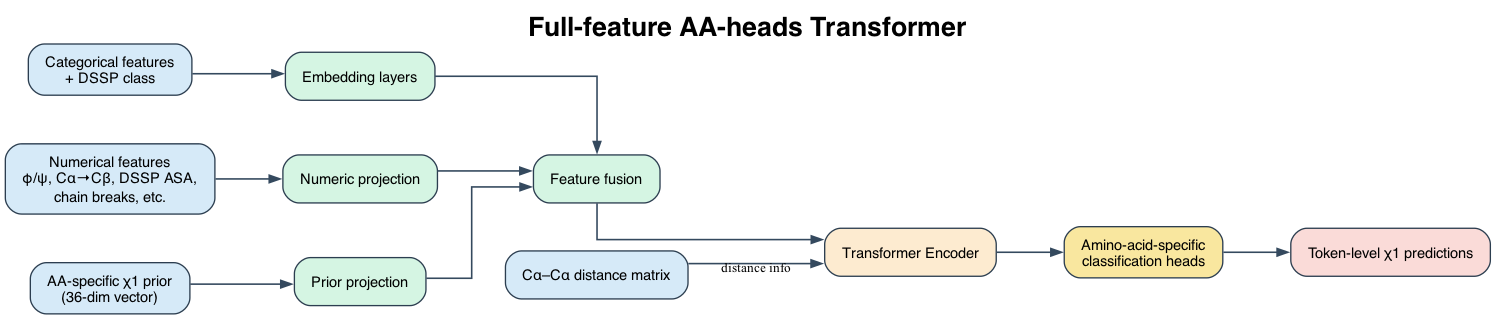

'model_diagrams/full-feature_aa-heads_transformer.png'

In [6]:
full_blocks = [
    ("cat", "Categorical features\n+ DSSP class", INPUT_COLOR),
    ("num", "Numerical features\nφ/ψ, Cα→Cβ, DSSP ASA,\nchain breaks, etc.", INPUT_COLOR),
    ("dist", "Cα–Cα distance matrix", INPUT_COLOR),
    ("prior", "AA-specific χ1 prior\n(36-dim vector)", INPUT_COLOR),
    ("emb", "Embedding layers", FEATURE_COLOR),
    ("numproj", "Numeric projection", FEATURE_COLOR),
    ("priorproj", "Prior projection", FEATURE_COLOR),
    ("merge", "Feature fusion", FEATURE_COLOR),
    ("enc", "Transformer Encoder", ENCODER_COLOR),
    ("heads", "Amino-acid-specific\nclassification heads", SPECIAL_COLOR),
    ("out", "Token-level χ1 predictions", OUTPUT_COLOR),
]

full_edges = [
    ("cat", "emb", ""),
    ("num", "numproj", ""),
    ("prior", "priorproj", ""),
    ("emb", "merge", ""),
    ("numproj", "merge", ""),
    ("priorproj", "merge", ""),
    ("merge", "enc", ""),
    ("dist", "enc", "distance info"),
    ("enc", "heads", ""),
    ("heads", "out", ""),
]

draw_model_diagram("Full-feature AA-heads Transformer", full_blocks, full_edges)